In [2]:
# # At the top of the Colab notebook, mount Drive if needed:
# from google.colab import drive
# drive.mount('/content/drive')

# ### NOTE #####
# # Uncomment to Mount Google Drive (permissions needed)

# Compute Biofoul Intensity on a given image

Continuous fouling coverage regression from underwater inspection images using weakly supervised coverage estimation.
Based on: Mannix et al. (2021), Scientific Reports.

Uses Class Activation Mapping (CAM) to estimate TRUE coverage percentage from images, without requiring pixel-level mask annotations.

HOW IT WORKS:
  1. Train a classifier (SLoF 0/1/2) with Global Average Pooling
  2. Extract Class Activation Maps showing "where the model looks"
  3. Threshold CAM to get binary fouled/clean mask
  4. Count fouled pixels → actual coverage %


ARCHITECTURE CHANGE:
  New: Image → CNN → GAP + Classifier → CAM → Real pixel count → True %

Based on: Zhou et al. (2016) "Learning Deep Features for Discriminative 
Localization" (Class Activation Mapping paper)

In [3]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.1/40.2 MB 777.7 kB/s eta 0:00:52
   ---------------------------------------- 0.4/40.2 MB 2.9 MB/s eta 0:00:14
   - -------------------------------------- 1.7/40.2 MB 9.6 MB/s eta 0:00:05
   ---- ----------------------------------- 4.5/40.2 MB 20.4 MB/s eta 0:00:02
   ------ --------------------------------- 6.8/40.2 MB 27.2 MB/s eta 0:00:02
   --------- ------------------------------ 9.5/40.2 MB 30.4 MB/s eta 0:00:02
   ------------- -------------------------- 13.8/40.2 MB 65.6 MB/s eta 0:00:01
   ---------------- ----------------------- 16.6/40.2 MB 65.2 MB/s eta 0:00:01
   ------------------ --------------------- 18.7/40.2 MB 65.2 MB/s eta 0:00:01
   --------------------- ------------------ 21.5/40.2 MB 59.8 MB/s eta 0:00:01
   ------------------------ --------------- 25.0/40.2 MB 59.5 MB/s eta 0:00:0

  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.3 which is incompatible.
numba 0.59.1 requires numpy<1.27,>=1.22, but you have numpy 2.4.3 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.4.3 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.4.3 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.4.3 which is incompatible.


In [5]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import cv2
import random

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import MultiStepLR

from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python 3.12 from "C:\Users\Joshua\anaconda3\python.exe"
  * The NumPy version is: "1.26.4"

and make sure that they are the versions you expect.

Please carefully study the information and documentation linked above.
This is unlikely to be a NumPy issue but will be caused by a bad install
or environment on your machine.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: numpy._core.multiarray failed to import

In [4]:
# Setup
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = (
    torch.device("cuda")  if torch.cuda.is_available()  else
    torch.device("mps")   if torch.backends.mps.is_available() else
    torch.device("cpu")
)
print(f"Using device: {DEVICE}")

Using device: cuda


## Load Datasets

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


def get_transforms(img_size=512, mode="train"):
    """Augmentation pipeline for underwater imagery."""
    if mode == "train":
        return transforms.Compose([
            transforms.Resize((img_size + 32, img_size + 32)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=20),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, 
                                   saturation=0.3, hue=0.06),
            transforms.RandomGrayscale(p=0.05),
            transforms.RandomApply([
                transforms.GaussianBlur(kernel_size=5, sigma=(0.5, 2.5))
            ], p=0.3),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.2, scale=(0.02, 0.12)),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])


class BiofoulDataset(Dataset):
    """
    Dataset for SLoF classification (used to train the CAM model).
    Target is now the SLoF class (0/1/2), not a coverage %.
    """
    def __init__(self, df, image_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.transform = transform
        self.targets = df["slof"].values  # Now using class labels directly
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_dir / row["filename"]
        
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        
        target = torch.tensor(self.targets[idx], dtype=torch.long)
        return img, target


def load_data(csv_path, image_dir, img_size=512, 
              val_split=0.15, test_split=0.15, seed=SEED):
    """Load and split data."""
    # Check if file exists first
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"CSV file not found at: {csv_path}\n"
            f"Please check the path in CONFIG['data_csv']"
        )
    
    df = pd.read_csv(csv_path)
    
    print(f"\nLoaded CSV with {len(df)} rows")
    print(f"Original columns: {list(df.columns)}")
    
    # Normalize column names: strip whitespace, lowercase, replace dots with underscores
    df.columns = df.columns.str.strip().str.lower().str.replace('.', '_')
    
    print(f"Normalized columns: {list(df.columns)}")
    
    # Map common variations to expected names
    if "image_name" in df.columns and "filename" not in df.columns:
        df["filename"] = df["image_name"]
        print("  Mapped 'image_name' → 'filename'")
    
    # Check for required columns
    if "filename" not in df.columns or "slof" not in df.columns:
        raise ValueError(
            f"CSV must have columns that map to 'filename' and 'slof'.\n"
            f"Found columns after normalization: {list(df.columns)}\n"
            f"Expected: 'filename' (or 'image_name', 'image.name') and 'slof' (or 'SLoF')"
        )
    
    # Validate SLoF values
    print(f"\nSLoF value distribution:")
    print(df["slof"].value_counts().sort_index())
    
    invalid = set(df["slof"].unique()) - {0, 1, 2}
    if invalid:
        raise ValueError(f"Invalid SLoF values found: {invalid}. Must be 0, 1, or 2.")
    
    # # Stratified split
    # if "split" in df.columns:
    #     print("\nUsing pre-existing 'split' column from CSV")
    #     train_df = df[df["split"] == "train"].copy()
    #     val_df = df[df["split"] == "val"].copy()
    #     test_df = df[df["split"] == "test"].copy()
        
    #     if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
    #         print("WARNING: Some splits are empty. Creating new splits...")
    #         # Fall through to create new splits
    #         train_df, temp_df = train_test_split(
    #             df, test_size=val_split + test_split, 
    #             stratify=df["slof"], random_state=seed
    #         )
    #         val_df, test_df = train_test_split(
    #             temp_df, test_size=test_split / (val_split + test_split),
    #             stratify=temp_df["slof"], random_state=seed
    #         )
    # else:
    #     print("\nNo 'split' column found. Creating stratified splits...")
    #     train_df, temp_df = train_test_split(
    #         df, test_size=val_split + test_split, 
    #         stratify=df["slof"], random_state=seed
    #     )
    #     val_df, test_df = train_test_split(
    #         temp_df, test_size=test_split / (val_split + test_split),
    #         stratify=temp_df["slof"], random_state=seed
    #     )
    #### Stratified Splits #####
    print("\nCreating fresh stratified train/val/test splits...")
    print(f"  Ignoring any pre-existing 'split' column in CSV")
    train_df, temp_df = train_test_split(
        df, test_size=val_split + test_split,
        stratify=df["slof"], random_state=seed
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=test_split/ (val_split + test_split),
        stratify=temp_df["slof"], random_state=seed
    )

    print(f"\nDataset splits:")
    print(f"  Train: {len(train_df):>5,}  Val: {len(val_df):>5,}  Test: {len(test_df):>5,}")
    
    # Print class distribution
    for name, subset in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        dist = subset["slof"].value_counts(normalize=True).sort_index() * 100
        print(f"  {name} → " + " | ".join([f"SLoF{i}: {dist.get(i, 0):.1f}%" for i in range(3)]))
    

    train_ds = BiofoulDataset(train_df, image_dir, get_transforms(img_size, "train"))
    val_ds = BiofoulDataset(val_df, image_dir, get_transforms(img_size, "val"))
    test_ds = BiofoulDataset(test_df, image_dir, get_transforms(img_size, "test"))
    
    return train_ds, val_ds, test_ds, df


## Model Building

In [6]:
class CAMModel(nn.Module):
    """
    Classification model with Global Average Pooling that enables
    Class Activation Mapping for coverage estimation.
    
    Architecture:
      Image → Conv layers → [Feature maps] → GAP → FC → SLoF class
      
    The feature maps before GAP are used to compute spatial attention (CAM),
    which shows where fouling is located. We threshold this to get coverage %.
    
    Key difference from regression model:
      - Uses GAP instead of flattening
      - Outputs class logits (0/1/2) not a single regression value
      - Feature maps are accessible for CAM computation
    """
    
    def __init__(self, backbone="efficientnet_b4", num_classes=3, dropout=0.4):
        super().__init__()
        
        # More accuracy - higher runtime
        if backbone == "efficientnet_b4":
            base = models.efficientnet_b4(
                weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1
            )
            # Remove the original classifier
            self.features = base.features  # Convolutional feature extractor
            feature_dim = 1792
        # Less accuracy (1-3%) - 40% less runtime
        elif backbone == "efficientnet_b3":
            base = models.efficientnet_b3(
                weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1
            )
            # Remove the original classifier
            self.features = base.features  # Convolutional feature extractor
            feature_dim = 1536
        # Fastest model     
        elif backbone == "resnet18":
            base = models.resnet18(
                weights=models.ResNet18_Weights.IMAGENET1K_V1
            )
            # Remove FC layer, keep conv layers
            self.features = nn.Sequential(*list(base.children())[:-2])
            feature_dim = 512            
        # Alternative model - untested   
        elif backbone == "resnet50":
            base = models.resnet50(
                weights=models.ResNet50_Weights.IMAGENET1K_V1
            )
            # Remove FC layer, keep conv layers
            self.features = nn.Sequential(*list(base.children())[:-2])
            feature_dim = 2048
            
        else:
            raise ValueError(f"Backbone {backbone} not supported")
        
        # Global Average Pooling (critical for CAM)
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(feature_dim, num_classes)
        )
        
        self.backbone_name = backbone
        self.feature_dim = feature_dim
        
        # Hook to capture feature maps for CAM
        self.feature_maps = None
        def hook_fn(module, input, output):
            self.feature_maps = output
        self.features.register_forward_hook(hook_fn)
    
    def forward(self, x):
        # Extract feature maps (B, C, H, W)
        features = self.features(x)
        
        # Global average pooling (B, C, H, W) → (B, C, 1, 1)
        pooled = self.gap(features).flatten(1)
        
        # Classification logits
        logits = self.classifier(pooled)
        
        return logits
    
    def get_cam(self, class_idx, feature_maps=None):
        """
        Compute Class Activation Map for a given class.
        
        CAM formula:
          CAM_c(x,y) = Σ_k w_k^c · f_k(x,y)
          
        where:
          w_k^c = weight of feature map k for class c
          f_k(x,y) = activation at spatial location (x,y) in feature map k
        
        Returns:
          cam: (H, W) numpy array with spatial attention scores
        """
        if feature_maps is None:
            feature_maps = self.feature_maps
        
        # Get classifier weights for the target class
        # Shape: (feature_dim,)
        weights = self.classifier[1].weight[class_idx].detach().cpu()
        
        # Feature maps shape: (B, C, H, W)
        # Take first batch item: (C, H, W)
        fmaps = feature_maps[0].detach().cpu()
        
        # Weighted sum: Σ_k w_k · f_k(x,y)
        cam = torch.zeros(fmaps.shape[1:])  # (H, W)
        for i, w in enumerate(weights):
            cam += w * fmaps[i]
        
        # ReLU to keep only positive activations
        cam = F.relu(cam)
        
        # Normalize to [0, 1]
        cam = cam.numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        return cam


In [7]:
def plot_confusion_and_examples(preds, targets, epoch, output_dir):
    """
    Plot confusion matrix and per-class metrics to visualize
    if the model is learning correctly.
    """
    try:
        from sklearn.metrics import confusion_matrix, classification_report
        
        # Confusion matrix
        cm = confusion_matrix(targets, preds, labels=[0, 1, 2])
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 1. Confusion matrix
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=['SLoF 0', 'SLoF 1', 'SLoF 2'],
                    yticklabels=['SLoF 0', 'SLoF 1', 'SLoF 2'],
                    ax=axes[0], vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
        axes[0].set_xlabel('Predicted SLoF')
        axes[0].set_ylabel('True SLoF')
        axes[0].set_title(f'Confusion Matrix (Epoch {epoch})\nNormalized by row')
        
        # 2. Per-class metrics
        report = classification_report(targets, preds, 
                                       labels=[0, 1, 2],
                                       target_names=['SLoF 0', 'SLoF 1', 'SLoF 2'],
                                       output_dict=True, zero_division=0)
        
        classes = ['SLoF 0', 'SLoF 1', 'SLoF 2']
        precision = [report[c]['precision'] for c in classes]
        recall = [report[c]['recall'] for c in classes]
        f1 = [report[c]['f1-score'] for c in classes]
        
        x = np.arange(len(classes))
        width = 0.25
        
        axes[1].bar(x - width, precision, width, label='Precision', alpha=0.8)
        axes[1].bar(x, recall, width, label='Recall', alpha=0.8)
        axes[1].bar(x + width, f1, width, label='F1-Score', alpha=0.8)
        
        axes[1].set_xlabel('SLoF Class')
        axes[1].set_ylabel('Score')
        axes[1].set_title(f'Per-Class Metrics (Epoch {epoch})')
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(classes)
        axes[1].legend()
        axes[1].set_ylim([0, 1.05])
        axes[1].grid(True, alpha=0.3, axis='y')
        
        # Add sample counts
        for i, cls in enumerate(classes):
            support = report[cls]['support']
            axes[1].text(i, -0.08, f'n={int(support)}', 
                        ha='center', va='top', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(output_dir / f"validation_metrics_epoch{epoch:03d}.png", 
                   dpi=120, bbox_inches='tight')
        plt.close()
        
        # Print detailed report to console
        if epoch % 10 == 0:
            print(f"\n  Validation Metrics (Epoch {epoch}):")
            print(f"  " + "─" * 60)
            for cls in classes:
                print(f"  {cls}: Precision={report[cls]['precision']:.3f}  "
                      f"Recall={report[cls]['recall']:.3f}  "
                      f"F1={report[cls]['f1-score']:.3f}  "
                      f"(n={int(report[cls]['support'])})")
            print(f"  " + "─" * 60)
            
            # Check for class imbalance issues
            worst_class = min(classes, key=lambda c: report[c]['f1-score'])
            if report[worst_class]['f1-score'] < 0.5:
                print(f"  ⚠️  WARNING: {worst_class} has low F1-score ({report[worst_class]['f1-score']:.3f})")
                print(f"      Model is struggling with this class!")
    
    except Exception as e:
        print(f"  Warning: Could not create validation plots: {e}")


def run_epoch(model, loader, criterion, optimizer, device, training=True):
    """Run one epoch of training or evaluation."""
    model.train() if training else model.eval()
    
    total_loss = 0.0
    all_preds, all_targets = [], []
    
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            
            logits = model(images)
            loss = criterion(logits, targets)
            
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            
            total_loss += loss.item() * len(images)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    avg_loss = total_loss / len(loader.dataset)
    accuracy = float(np.mean(all_preds == all_targets))
    
    return avg_loss, accuracy, all_preds, all_targets


# def train_model(model, train_loader, val_loader, criterion, optimizer, 
#                 scheduler, epochs=100, patience=15, output_dir="outputs"):
#     """Training loop with early stopping."""
#     output_dir = Path(output_dir)
#     output_dir.mkdir(parents=True, exist_ok=True)
    
#     best_val_acc = 0.0
#     patience_ctr = 0
#     history = {"train_loss": [], "val_loss": [], 
#                "train_acc": [], "val_acc": []}
    
#     print(f"\nTraining for {epochs} epochs...")
#     print("─" * 70)
    
#     for epoch in range(1, epochs + 1):
#         train_loss, train_acc, _, _ = run_epoch(
#             model, train_loader, criterion, optimizer, DEVICE, training=True
#         )
#         val_loss, val_acc, val_preds, val_targets = run_epoch(
#             model, val_loader, criterion, optimizer, DEVICE, training=False
#         )
        
#         scheduler.step()
        
#         history["train_loss"].append(train_loss)
#         history["val_loss"].append(val_loss)
#         history["train_acc"].append(train_acc)
#         history["val_acc"].append(val_acc)
        
#         print(f"Epoch {epoch:03d}/{epochs} | "
#               f"Train acc: {train_acc:.3f}  loss: {train_loss:.4f}  | "
#               f"Val acc: {val_acc:.3f}  loss: {val_loss:.4f}")
        
#         # Save best checkpoint
#         if val_acc > best_val_acc:
#             best_val_acc = val_acc
#             patience_ctr = 0
#             torch.save({
#                 "epoch": epoch,
#                 "model_state": model.state_dict(),
#                 "val_acc": val_acc,
#                 "backbone": model.backbone_name,
#             }, output_dir / "best_model.pth")
#             print(f"  ✓ Best model saved (acc {best_val_acc:.3f})")
#         else:
#             patience_ctr += 1
#             if patience_ctr >= patience:
#                 print(f"\nEarly stopping at epoch {epoch}")
#                 break
    
#     # Save training curves
#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#     epochs_range = range(1, len(history["train_loss"]) + 1)
    
#     axes[0].plot(epochs_range, history["train_loss"], label="Train")
#     axes[0].plot(epochs_range, history["val_loss"], label="Val")
#     axes[0].set_title("Cross-Entropy Loss")
#     axes[0].set_xlabel("Epoch")
#     axes[0].legend()
#     axes[0].grid(True, alpha=0.3)
    
#     axes[1].plot(epochs_range, history["train_acc"], label="Train")
#     axes[1].plot(epochs_range, history["val_acc"], label="Val")
#     axes[1].set_title("SLoF Classification Accuracy")
#     axes[1].set_xlabel("Epoch")
#     axes[1].set_ylabel("Accuracy")
#     axes[1].legend()
#     axes[1].grid(True, alpha=0.3)
    
#     plt.tight_layout()
#     plt.savefig(output_dir / "training_curves.png", dpi=150)
#     print(f"\n  Saved training curves → {output_dir / 'training_curves.png'}")
    
#     return best_val_acc


In [8]:
def train_model(model, train_loader, val_loader, criterion, optimizer, 
                scheduler, epochs=100, patience=15, output_dir="outputs", config = None):
    """Training loop with early stopping and visualization."""
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    best_val_acc = 0.0
    patience_ctr = 0
    history = {"train_loss": [], "val_loss": [], 
               "train_acc": [], "val_acc": []}
    
    print(f"\nTraining for {epochs} epochs...")
    print("─" * 70)
    
    for epoch in range(1, epochs + 1):
        train_loss, train_acc, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, DEVICE, training=True
        )
        val_loss, val_acc, val_preds, val_targets = run_epoch(
            model, val_loader, criterion, optimizer, DEVICE, training=False
        )
        
        scheduler.step()
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch:03d}/{epochs} | "
              f"Train acc: {train_acc:.3f}  loss: {train_loss:.4f}  | "
              f"Val acc: {val_acc:.3f}  loss: {val_loss:.4f}")
        
        # Visualize predictions every 20 epochs
        if epoch % 20 == 0 or epoch == 1:
            plot_confusion_and_examples(
                val_preds, val_targets, epoch, output_dir
            )
        
        # Save best checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "val_acc": val_acc,
                "backbone": model.backbone_name,
                "config": config,
            }, output_dir / "best_model.pth")
            print(f"  ✓ Best model saved (acc {best_val_acc:.3f})")
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f"\nEarly stopping at epoch {epoch}")
                break
    
    # Save training curves with overfitting detection
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs_range = range(1, len(history["train_loss"]) + 1)
    
    # 1. Loss curves
    axes[0, 0].plot(epochs_range, history["train_loss"], label="Train", linewidth=2)
    axes[0, 0].plot(epochs_range, history["val_loss"], label="Val", linewidth=2)
    axes[0, 0].set_title("Cross-Entropy Loss", fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Add overfitting warning if val loss increases
    if len(history["val_loss"]) > 10:
        recent_val_trend = np.polyfit(range(10), 
                                       history["val_loss"][-10:], 1)[0]
        if recent_val_trend > 0.01:
            axes[0, 0].text(0.5, 0.95, "⚠️ OVERFITTING DETECTED", 
                           transform=axes[0, 0].transAxes,
                           fontsize=10, color='red', fontweight='bold',
                           ha='center', va='top',
                           bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
    
    # 2. Accuracy curves
    axes[0, 1].plot(epochs_range, history["train_acc"], label="Train", linewidth=2)
    axes[0, 1].plot(epochs_range, history["val_acc"], label="Val", linewidth=2)
    axes[0, 1].set_title("Classification Accuracy", fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_ylim([0, 1])
    
    # 3. Train-Val gap (overfitting indicator)
    loss_gap = np.array(history["val_loss"]) - np.array(history["train_loss"])
    acc_gap = np.array(history["train_acc"]) - np.array(history["val_acc"])
    
    axes[1, 0].plot(epochs_range, loss_gap, label="Val Loss - Train Loss", 
                    color='orange', linewidth=2)
    axes[1, 0].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1, 0].fill_between(epochs_range, 0, loss_gap, 
                            where=(loss_gap > 0), alpha=0.3, color='red', 
                            label='Overfitting zone')
    axes[1, 0].set_title("Loss Gap (Overfitting Indicator)", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Val Loss - Train Loss")
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Learning rate schedule visualization
    axes[1, 1].plot(epochs_range, acc_gap, label="Train Acc - Val Acc",
                    color='purple', linewidth=2)
    axes[1, 1].axhline(0, color='gray', linestyle='--', alpha=0.5)
    axes[1, 1].fill_between(epochs_range, 0, acc_gap,
                            where=(acc_gap > 0), alpha=0.3, color='red',
                            label='Overfitting zone')
    axes[1, 1].set_title("Accuracy Gap", fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Train Acc - Val Acc")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / "training_curves.png", dpi=150, bbox_inches='tight')
    print(f"\n  Saved training curves → {output_dir / 'training_curves.png'}")
    
    return best_val_acc


In [9]:
def estimate_coverage_from_cam(model, image_tensor, predicted_class, 
                                cam_threshold=0.5):
    """
    Estimate coverage percentage using Class Activation Mapping.
    
    Steps:
      1. Forward pass through model to get feature maps
      2. Compute CAM for the predicted class
      3. Threshold CAM to get binary fouled/clean mask
      4. Count percentage of "fouled" pixels
    
    Args:
        model: Trained CAM model
        image_tensor: (1, 3, H, W) normalized image
        predicted_class: SLoF class (0/1/2)
        cam_threshold: Threshold for binarizing CAM (default 0.5)
    
    Returns:
        coverage_pct: float, percentage of image that is fouled (0-100)
        cam: (H, W) numpy array, the activation map
        binary_mask: (H, W) bool array, thresholded mask
    """
    model.eval()
    
    with torch.no_grad():
        _ = model(image_tensor.to(DEVICE))  # Forward pass captures feature maps
    
    # If predicted class is 0 (clean), coverage is 0
    if predicted_class == 0:
        h, w = image_tensor.shape[2:]
        return 0.0, np.zeros((h, w)), np.zeros((h, w), dtype=bool)
    
    # Get CAM for predicted class
    cam = model.get_cam(predicted_class)
    
    # Resize CAM to match original image size
    target_size = (image_tensor.shape[2], image_tensor.shape[3])  # (H, W)
    cam_resized = cv2.resize(cam, (target_size[1], target_size[0]))
    
    # Threshold to get binary mask
    binary_mask = cam_resized > cam_threshold
    
    # Coverage = percentage of pixels above threshold
    coverage_pct = float(binary_mask.sum() / binary_mask.size * 100)
    
    return coverage_pct, cam_resized, binary_mask


def visualize_cam(image_path, cam, binary_mask, coverage_pct, predicted_slof, 
                  output_path=None):
    """
    Create visualization showing:
      - Original image
      - CAM heatmap overlay
      - Binary mask
      - Coverage statistics
    """
    # Load original image
    img = Image.open(image_path).convert("RGB")
    img_np = np.array(img)
    
    # Create figure
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    # 1. Original image
    axes[0].imshow(img_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    # 2. CAM heatmap overlay
    cam_colored = plt.cm.jet(cam)[:, :, :3]  # Apply colormap
    # Resize CAM to match original image size (FIX)
    if cam.shape != img_np.shape[:2]:
        cam_colored = cv2.resize(cam_colored, (img_np.shape[1], img_np.shape[0]))
    overlay = (img_np / 255.0 * 0.5 + cam_colored * 0.5)
    axes[1].imshow(overlay)
    axes[1].set_title(f"Class Activation Map\n(SLoF {predicted_slof})")
    axes[1].axis("off")
    
    # 3. Binary mask
    axes[2].imshow(binary_mask, cmap="RdYlGn_r")
    axes[2].set_title(f"Fouled Regions\n(Red = Fouled)")
    axes[2].axis("off")
    
    # 4. Statistics
    axes[3].axis("off")
    stats_text = f"""
    COVERAGE ESTIMATION
    ═══════════════════
    
    Predicted SLoF: {predicted_slof}
    
    Coverage: {coverage_pct:.1f}%
    
    Interpretation:
    {"Clean hull" if predicted_slof == 0 else ""}
    {"Light patchy fouling" if predicted_slof == 1 else ""}
    {"Heavy fouling" if predicted_slof == 2 else ""}
    
    Method: Class Activation
    Mapping (CAM) + threshold
    """
    axes[3].text(0.1, 0.5, stats_text, fontsize=11, family="monospace",
                verticalalignment="center")
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
    else:
        plt.show()
    
    plt.close()


# @torch.no_grad()
# def evaluate_coverage(model, test_loader, test_df, image_dir, 
#                       output_dir="outputs", cam_threshold=0.5, 
#                       visualize_samples=10):
#     """
#     Evaluate coverage estimation on test set.
    
#     For each image:
#       1. Classify into SLoF class
#       2. Generate CAM
#       3. Estimate coverage %
#       4. Save results to CSV
#       5. Visualize a few examples
#     """
#     model.eval()
#     output_dir = Path(output_dir)
#     vis_dir = output_dir / "cam_visualizations"
#     vis_dir.mkdir(parents=True, exist_ok=True)
    
#     results = []
    
#     print(f"\nEstimating coverage on {len(test_loader.dataset)} test images...")
    
#     for idx, (images, targets) in enumerate(test_loader):
#         batch_size = images.shape[0]
        
#         for i in range(batch_size):
#             img_tensor = images[i:i+1]
#             true_slof = targets[i].item()
            
#             # Classify
#             logits = model(img_tensor.to(DEVICE))
#             pred_slof = logits.argmax(dim=1).item()
            
#             # Estimate coverage via CAM
#             coverage, cam, mask = estimate_coverage_from_cam(
#                 model, img_tensor, pred_slof, cam_threshold
#             )
            
#             # Get filename
#             global_idx = idx * test_loader.batch_size + i
#             filename = test_df.iloc[global_idx]["filename"]
            
#             results.append({
#                 "filename": filename,
#                 "true_slof": true_slof,
#                 "predicted_slof": pred_slof,
#                 "estimated_coverage_pct": round(coverage, 2),
#             })
            
#             # Visualize first N samples
#             if global_idx < visualize_samples:
#                 img_path = Path(image_dir) / filename
#                 vis_path = vis_dir / f"sample_{global_idx:03d}_{filename}"
#                 visualize_cam(img_path, cam, mask, coverage, pred_slof, vis_path)
    
#     # Save results CSV
#     results_df = pd.DataFrame(results)
#     results_df.to_csv(output_dir / "coverage_estimates.csv", index=False)
#     print(f"  Saved coverage estimates → {output_dir / 'coverage_estimates.csv'}")
#     print(f"  Saved {visualize_samples} visualizations → {vis_dir}/")
    
#     # Compute statistics
#     print(f"\n{'='*60}")
#     print(f"  COVERAGE ESTIMATION RESULTS")
#     print(f"{'='*60}")
#     print(f"  SLoF classification accuracy: "
#           f"{(results_df['true_slof'] == results_df['predicted_slof']).mean():.3f}")
#     print(f"\n  Coverage statistics:")
#     print(f"    Mean coverage: {results_df['estimated_coverage_pct'].mean():.1f}%")
#     print(f"    Median coverage: {results_df['estimated_coverage_pct'].median():.1f}%")
#     print(f"    Std dev: {results_df['estimated_coverage_pct'].std():.1f}%")
#     print(f"\n  Coverage by predicted SLoF class:")
#     for slof in [0, 1, 2]:
#         subset = results_df[results_df["predicted_slof"] == slof]
#         if len(subset) > 0:
#             print(f"    SLoF {slof}: {subset['estimated_coverage_pct'].mean():.1f}% "
#                   f"(n={len(subset)})")
#     print(f"{'='*60}\n")
    
#     return results_df


@torch.no_grad()
def evaluate_coverage(model, test_loader, test_df, image_dir, 
                      output_dir="outputs", cam_threshold=0.5, 
                      visualize_samples=10):
    """
    Evaluate coverage estimation on test set.
    
    For each image:
      1. Classify into SLoF class
      2. Generate CAM
      3. Estimate coverage %
      4. Save results to CSV
      5. Visualize a few examples
    """
    model.eval()
    output_dir = Path(output_dir)
    vis_dir = output_dir / "cam_visualizations"
    vis_dir.mkdir(parents=True, exist_ok=True)
    
    results = []
    
    print(f"\nEstimating coverage on {len(test_loader.dataset)} test images...")
    
    for idx, (images, targets) in enumerate(test_loader):
        batch_size = images.shape[0]
        
        for i in range(batch_size):
            img_tensor = images[i:i+1]
            true_slof = targets[i].item()
            
            # Classify
            logits = model(img_tensor.to(DEVICE))
            pred_slof = logits.argmax(dim=1).item()
            
            # Estimate coverage via CAM
            coverage, cam, mask = estimate_coverage_from_cam(
                model, img_tensor, pred_slof, cam_threshold
            )
            
            # Get filename
            global_idx = idx * test_loader.batch_size + i
            filename = test_df.iloc[global_idx]["filename"]
            
            results.append({
                "filename": filename,
                "true_slof": true_slof,
                "predicted_slof": pred_slof,
                "estimated_coverage_pct": round(coverage, 2),
            })
            
            # Visualize first N samples
            if global_idx < visualize_samples:
                img_path = Path(image_dir) / filename
                vis_path = vis_dir / f"sample_{global_idx:03d}_{filename}"
                visualize_cam(img_path, cam, mask, coverage, pred_slof, vis_path)
    
    # Save results CSV
    results_df = pd.DataFrame(results)
    results_df.to_csv(output_dir / "coverage_estimates.csv", index=False)
    print(f"  Saved coverage estimates → {output_dir / 'coverage_estimates.csv'}")
    print(f"  Saved {visualize_samples} visualizations → {vis_dir}/")
    
    # Compute statistics
    print(f"\n{'='*60}")
    print(f"  COVERAGE ESTIMATION RESULTS")
    print(f"{'='*60}")
    print(f"  SLoF classification accuracy: "
          f"{(results_df['true_slof'] == results_df['predicted_slof']).mean():.3f}")
    print(f"\n  Confusion Matrix:")
    cm = confusion_matrix(results_df['true_slof'], results_df['predicted_slof'], 
                         labels=[0, 1, 2])
    cm_df = pd.DataFrame(cm, 
                         index=['True SLoF 0', 'True SLoF 1', 'True SLoF 2'],
                         columns=['Pred SLoF 0', 'Pred SLoF 1', 'Pred SLoF 2'])
    print(cm_df)
    
    print(f"\n  Coverage statistics:")
    print(f"    Mean coverage: {results_df['estimated_coverage_pct'].mean():.1f}%")
    print(f"    Median coverage: {results_df['estimated_coverage_pct'].median():.1f}%")
    print(f"    Std dev: {results_df['estimated_coverage_pct'].std():.1f}%")
    print(f"\n  Coverage by predicted SLoF class:")
    for slof in [0, 1, 2]:
        subset = results_df[results_df["predicted_slof"] == slof]
        if len(subset) > 0:
            print(f"    SLoF {slof}: {subset['estimated_coverage_pct'].mean():.1f}% "
                  f"± {subset['estimated_coverage_pct'].std():.1f}%  "
                  f"(n={len(subset)})")
    
    # Check for expected coverage patterns
    print(f"\n  Coverage pattern check:")
    slof0_mean = results_df[results_df["predicted_slof"]==0]["estimated_coverage_pct"].mean()
    slof1_mean = results_df[results_df["predicted_slof"]==1]["estimated_coverage_pct"].mean()
    slof2_mean = results_df[results_df["predicted_slof"]==2]["estimated_coverage_pct"].mean()
    
    if slof0_mean < slof1_mean < slof2_mean:
        print(f"    ✓ Coverage increases with SLoF class (as expected)")
    else:
        print(f"    ⚠️  WARNING: Coverage pattern unexpected!")
        print(f"       SLoF 0: {slof0_mean:.1f}%, SLoF 1: {slof1_mean:.1f}%, SLoF 2: {slof2_mean:.1f}%")
        print(f"       Check CAM visualizations and tune cam_threshold")
    
    print(f"{'='*60}\n")
    
    # Create comprehensive evaluation plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. Confusion matrix
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=['Pred 0', 'Pred 1', 'Pred 2'],
                yticklabels=['True 0', 'True 1', 'True 2'],
                ax=axes[0, 0], vmin=0, vmax=1)
    axes[0, 0].set_title('SLoF Classification\nConfusion Matrix (normalized)')
    
    # 2. Coverage distribution by true SLoF
    for slof in [0, 1, 2]:
        subset = results_df[results_df["true_slof"] == slof]
        if len(subset) > 0:
            axes[0, 1].hist(subset["estimated_coverage_pct"], bins=20, 
                           alpha=0.5, label=f'True SLoF {slof}', edgecolor='black')
    axes[0, 1].set_xlabel('Estimated Coverage (%)')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Coverage Distribution by True SLoF Class')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # 3. Coverage vs True SLoF (box plot)
    data_by_slof = [
        results_df[results_df["true_slof"]==0]["estimated_coverage_pct"].values,
        results_df[results_df["true_slof"]==1]["estimated_coverage_pct"].values,
        results_df[results_df["true_slof"]==2]["estimated_coverage_pct"].values,
    ]
    bp = axes[1, 0].boxplot(data_by_slof, labels=['SLoF 0', 'SLoF 1', 'SLoF 2'],
                            patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
        patch.set_facecolor(color)
    axes[1, 0].set_ylabel('Estimated Coverage (%)')
    axes[1, 0].set_xlabel('True SLoF Class')
    axes[1, 0].set_title('Coverage by True SLoF\n(Should increase: 0 < 1 < 2)')
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. Prediction correctness vs coverage
    results_df['correct'] = (results_df['true_slof'] == results_df['predicted_slof'])
    axes[1, 1].scatter(results_df['estimated_coverage_pct'], 
                      results_df['correct'].astype(int),
                      alpha=0.3, s=20)
    axes[1, 1].set_xlabel('Estimated Coverage (%)')
    axes[1, 1].set_ylabel('Prediction Correct (1=Yes, 0=No)')
    axes[1, 1].set_title('Does Coverage Help Classification?')
    axes[1, 1].set_ylim([-0.1, 1.1])
    axes[1, 1].grid(True, alpha=0.3)
    
    # Add accuracy at different coverage ranges
    for i, (low, high) in enumerate([(0, 5), (5, 20), (20, 100)]):
        subset = results_df[
            (results_df['estimated_coverage_pct'] >= low) & 
            (results_df['estimated_coverage_pct'] < high)
        ]
        if len(subset) > 10:
            acc = subset['correct'].mean()
            axes[1, 1].text((low + high)/2, 0.95 - i*0.1, 
                           f'{low}-{high}%: {acc:.2f} (n={len(subset)})',
                           ha='center', fontsize=9,
                           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(output_dir / "final_evaluation.png", dpi=150, bbox_inches='tight')
    print(f"  Saved final evaluation → {output_dir / 'final_evaluation.png'}")
    
    return results_df

In [10]:
# path = r"D:\Datasets\biofouling_dataset\metadata.csv"
path = "/content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/cam_effnetb4_test2"
print(os.path.exists(path))
path = "/content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/Datasets/biofouling_dataset/metadata.csv"
print(os.path.exists(path))
path = "/content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/Datasets/biofouling_dataset/images"
print(os.path.exists(path))

# Configuration
CONFIG = {
    "output_dir": "/content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/cam_effnetb4_test2",
    "data_csv": "/content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/Datasets/biofouling_dataset/metadata.csv",
    "image_dir": "/content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/Datasets/biofouling_dataset/images",
    
# CHECKPOINT HANDLING:
    "load_checkpoint": None,  # Set to "outputs/best_model.pth" to skip training
    "skip_training": False,   # Set True to only run evaluation (requires load_checkpoint)
    
    # "backbone": "efficientnet_b3",
    "backbone": "efficientnet_b4",
    # "backbone": "resnet18",
    "img_size": 512,  #can switch to 512
    "dropout": 0.6,
    
    "epochs": 40,
    "batch_size": 2,
    "weight_bias": 1.0,
    "lr": 5e-4,
    "weight_decay": 0.01,
    "patience": 5,
    
    "val_split": 0.15,
    "test_split": 0.15,
    "num_workers": 2,
    
    "cam_threshold": 0.3,  # Threshold for binarizing CAM (tune this!)
    "visualize_samples": 20,  # Number of test samples to visualize
}

# Save config as JSON for easy viewing --> Only saves it if model training is set to TRUE. 
if not CONFIG["skip_training"]:
    config_save = CONFIG.copy()
    config_save.pop("load_checkpoint", None)  # Remove non-serializable items
    with open(Path(CONFIG["output_dir"]) / "training_config.json", "w") as f:
        json.dump(config_save, f, indent=2)
    print(f"  Saved config → {CONFIG['output_dir']}/training_config.json")

True
True
True
  Saved config → /content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/cam_effnetb4_test2/training_config.json


In [11]:
# Load data
train_ds, val_ds, test_ds, full_df = load_data(
    CONFIG["data_csv"], CONFIG["image_dir"], 
    CONFIG["img_size"], CONFIG["val_split"], CONFIG["test_split"]
)

# ####### BALANCE CLASSES - Equal samples per class ############

# train_df_full = train_ds.df

# # Find smallest class
# class_counts = train_df_full["slof"].value_counts()
# min_class_size = class_counts.min()

# print(f"\n⚖️ BALANCING CLASSES (downsampling to {min_class_size} per class)")

# # Sample equally from each class
# balanced_dfs = []
# for slof in [0, 1, 2]:
#     class_df = train_df_full[train_df_full["slof"] == slof]
#     sampled_df = class_df.sample(n=min_class_size, random_state=42)
#     balanced_dfs.append(sampled_df)

# train_df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42)

# # Recreate dataset
# train_ds = BiofoulDataset(
#     train_df_balanced, 
#     CONFIG["image_dir"], 
#     get_transforms(CONFIG["img_size"], "train")
# )

# for slof in [0, 1, 2]:
#     count = (train_df_balanced["slof"] == slof).sum()
#     print(f"  SLoF {slof}: {count} images")

# ###############################################################

# ####### This set of code blocks reduces the size of the training data set ############ 
# ####### Uncomment if model is overfitting with existing number of training data ######

# REDUCTION_PERCENT = 0.2  # Adjust: 0.2 = 20%, 0.5 = 50%, 1.0 = 100% (no reduction)

# # Get original training data
# original_size = len(train_ds)
# train_df_full = train_ds.df

# # Create stratified reduced split using the 'slof' column directly from DataFrame
# train_df_reduced, _ = train_test_split(
#     train_df_full, 
#     train_size=REDUCTION_PERCENT,
#     stratify=train_df_full["slof"],  # ← CHANGED: Use DataFrame column, not targets
#     random_state=42
# )

# # Recreate dataset with reduced data
# train_ds = BiofoulDataset(
#     train_df_reduced, 
#     CONFIG["image_dir"], 
#     get_transforms(CONFIG["img_size"], "train")
# )

# # Verify reduction and class balance
# print(f"\n✂️ TRAINING DATA REDUCTION:")
# print(f"   Original: {original_size:>5,} images (100%)")
# print(f"   Reduced:  {len(train_ds):>5,} images ({int(REDUCTION_PERCENT*100)}%)")
# print(f"\n   Class distribution maintained:")

# # Use DataFrame to count classes (more reliable)
# for slof in [0, 1, 2]:
#     count = (train_df_reduced["slof"] == slof).sum()
#     pct = (count / len(train_df_reduced)) * 100
#     print(f"     SLoF {slof}: {count:>4} images ({pct:.1f}%)")

# ####################################################################################
# ####################################################################################

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"],
                          shuffle=True, num_workers=CONFIG["num_workers"],
                          pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"],
                        shuffle=False, num_workers=CONFIG["num_workers"],
                        pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"],
                         shuffle=False, num_workers=CONFIG["num_workers"],
                         pin_memory=True)



Loaded CSV with 10263 rows
Original columns: ['image.name', 'dataset.name', 'vessel.id', 'niche.area', 'SLoF', 'paint.quality', 'split']
Normalized columns: ['image_name', 'dataset_name', 'vessel_id', 'niche_area', 'slof', 'paint_quality', 'split']
  Mapped 'image_name' → 'filename'

SLoF value distribution:
slof
0    7822
1    1696
2     745
Name: count, dtype: int64

Creating fresh stratified train/val/test splits...
  Ignoring any pre-existing 'split' column in CSV

Dataset splits:
  Train: 7,184  Val: 1,539  Test: 1,540
  Train → SLoF0: 76.2% | SLoF1: 16.5% | SLoF2: 7.3%
  Val → SLoF0: 76.2% | SLoF1: 16.5% | SLoF2: 7.3%
  Test → SLoF0: 76.2% | SLoF1: 16.6% | SLoF2: 7.2%


In [12]:
# Initialize CAM model
model = CAMModel(CONFIG["backbone"], num_classes=3, dropout=CONFIG["dropout"]).to(DEVICE)
print(f"\nModel: {CONFIG['backbone']} with CAM")
total_params = sum(p.numel() for p in model.parameters())
print(f"  Total parameters: {total_params:,}")

# Check if we should load existing checkpoint
if CONFIG["load_checkpoint"] is not None:
    checkpoint_path = Path(CONFIG["load_checkpoint"])
    if checkpoint_path.exists():
        print(f"\n{'='*60}")
        print(f"  LOADING CHECKPOINT: {checkpoint_path}")
        print(f"{'='*60}")
        checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state"])
        print(f"  Loaded from epoch {checkpoint.get('epoch', '?')}")
        print(f"  Validation accuracy: {checkpoint.get('val_acc', '?'):.3f}")
        
        if CONFIG["skip_training"]:
            print(f"  skip_training=True: Skipping training, going straight to evaluation")
            best_val_acc = checkpoint.get('val_acc', 0.0)
        else:
            print(f"  Resuming training from this checkpoint...")
    else:
        print(f"\nWARNING: Checkpoint not found at {checkpoint_path}")
        print(f"  Starting training from scratch...")
        CONFIG["skip_training"] = False  # Force training if checkpoint doesn't exist


# Loss and optimizer
# Use class weights to handle imbalance
class_counts = np.bincount(train_ds.targets)
class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
class_weights = class_weights ** CONFIG["weight_bias"]
class_weights = class_weights / class_weights.sum()  # Normalize
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = AdamW(model.parameters(), lr=CONFIG["lr"], 
                  weight_decay=CONFIG["weight_decay"])

milestones = [
    int(CONFIG["epochs"] * 0.4),
    int(CONFIG["epochs"] * 0.7),
    int(CONFIG["epochs"] * 0.9),
]
scheduler = MultiStepLR(optimizer, milestones=milestones, gamma=0.1)


Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 196MB/s]



Model: efficientnet_b4 with CAM
  Total parameters: 17,553,995



Training for 40 epochs...
──────────────────────────────────────────────────────────────────────
Epoch 001/40 | Train acc: 0.769  loss: 1.1691  | Val acc: 0.765  loss: 1.5494
  ✓ Best model saved (acc 0.765)
Epoch 002/40 | Train acc: 0.781  loss: 0.9691  | Val acc: 0.807  loss: 0.9410
  ✓ Best model saved (acc 0.807)
Epoch 003/40 | Train acc: 0.793  loss: 0.9141  | Val acc: 0.814  loss: 0.9698
  ✓ Best model saved (acc 0.814)
Epoch 004/40 | Train acc: 0.795  loss: 0.8905  | Val acc: 0.801  loss: 1.1228
Epoch 005/40 | Train acc: 0.803  loss: 0.8470  | Val acc: 0.809  loss: 0.9302
Epoch 006/40 | Train acc: 0.804  loss: 0.8289  | Val acc: 0.821  loss: 0.9368
  ✓ Best model saved (acc 0.821)
Epoch 007/40 | Train acc: 0.812  loss: 0.8228  | Val acc: 0.824  loss: 1.0414
  ✓ Best model saved (acc 0.824)
Epoch 008/40 | Train acc: 0.812  loss: 0.7864  | Val acc: 0.816  loss: 1.0296
Epoch 009/40 | Train acc: 0.815  loss: 0.7830  | Val acc: 0.820  loss: 0.8706
Epoch 010/40 | Train acc: 0.817  lo

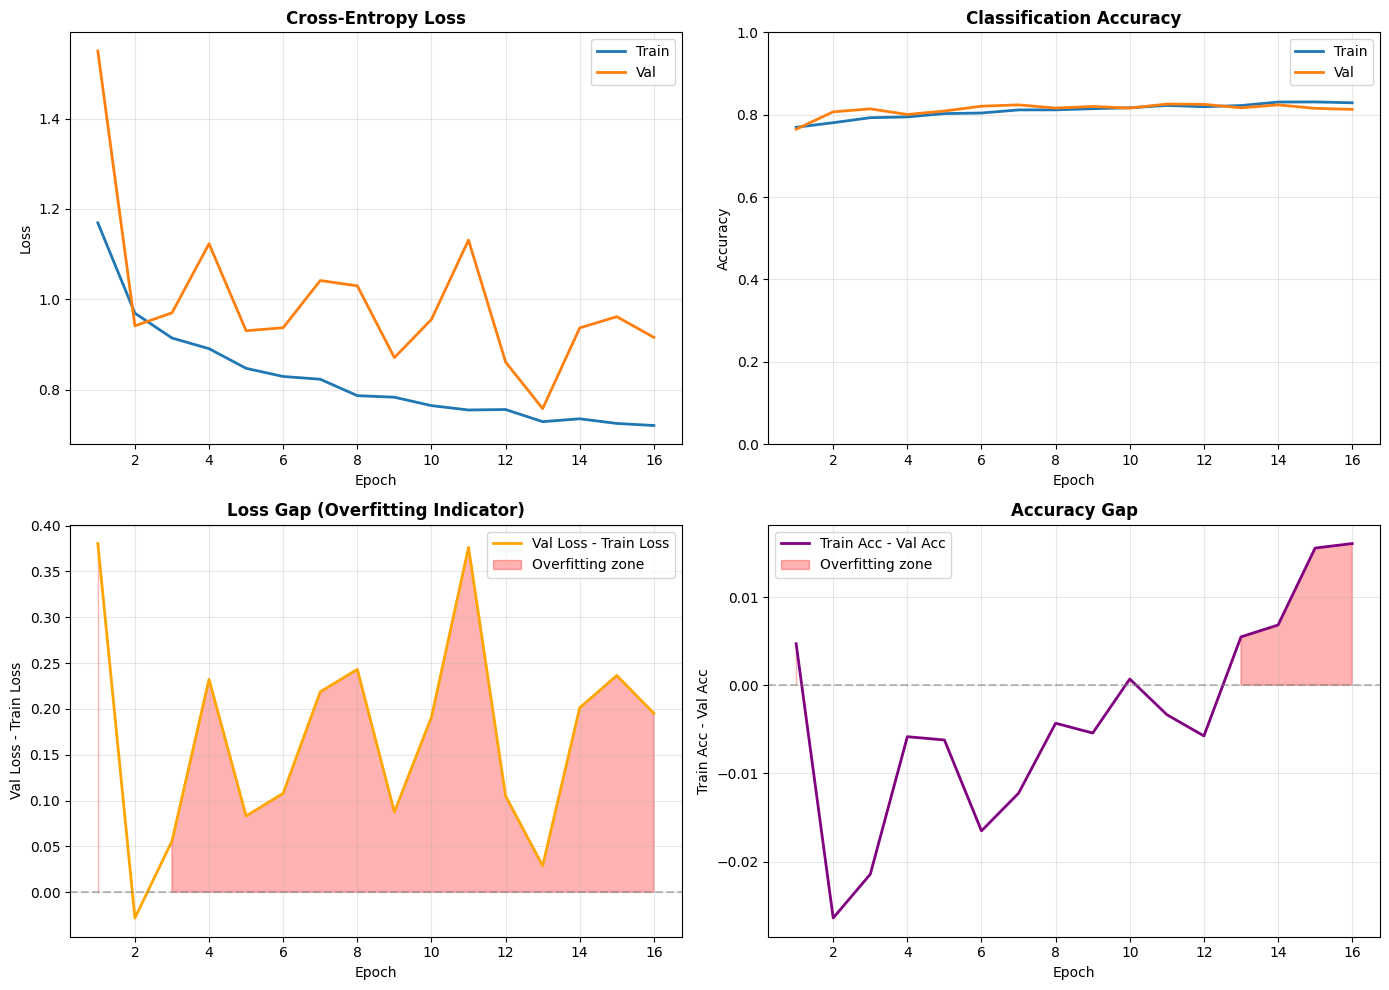

In [13]:
# # Train
# best_val_acc = train_model(
#     model, train_loader, val_loader, criterion, optimizer, scheduler,
#     epochs=CONFIG["epochs"], patience=CONFIG["patience"],
#     output_dir=CONFIG["output_dir"]
# )

# # Load best checkpoint
# checkpoint = torch.load(
#     Path(CONFIG["output_dir"]) / "best_model.pth", 
#     map_location=DEVICE
# )
# model.load_state_dict(checkpoint["model_state"])
# print(f"\nLoaded best checkpoint from epoch {checkpoint['epoch']}")


# Train (or skip if loading checkpoint with skip_training=True)
if not CONFIG["skip_training"]:
    best_val_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler,
        epochs=CONFIG["epochs"], patience=CONFIG["patience"],
        output_dir=CONFIG["output_dir"],
        config=CONFIG
    )
    
    # Load best checkpoint after training
    checkpoint = torch.load(
        Path(CONFIG["output_dir"]) / "best_model.pth", 
        map_location=DEVICE
    )
    model.load_state_dict(checkpoint["model_state"])
    print(f"\nLoaded best checkpoint from epoch {checkpoint['epoch']}")
else:
    print(f"\nSkipping training (using loaded checkpoint)")


Estimating coverage on 1540 test images...
  Saved coverage estimates → /content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/cam_effnetb4_test2/coverage_estimates.csv
  Saved 20 visualizations → /content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/cam_effnetb4_test2/cam_visualizations/

  COVERAGE ESTIMATION RESULTS
  SLoF classification accuracy: 0.803

  Confusion Matrix:
             Pred SLoF 0  Pred SLoF 1  Pred SLoF 2
True SLoF 0         1150           15            9
True SLoF 1          194           52            9
True SLoF 2           31           45           35

  Coverage statistics:
    Mean coverage: 0.6%
    Median coverage: 0.0%
    Std dev: 2.2%

  Coverage by predicted SLoF class:
    SLoF 0: 0.0% ± 0.0%  (n=1375)
    SLoF 1: 4.0% ± 2.1%  (n=112)
    SLoF 2: 9.0% ± 5.7%  (n=53)

  Coverage pattern check:
    ✓ Coverage increases with SLoF class (as expected)



/tmp/ipython-input-767/2213575322.py:331: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(data_by_slof, labels=['SLoF 0', 'SLoF 1', 'SLoF 2'],


  Saved final evaluation → /content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/cam_effnetb4_test2/final_evaluation.png

  TRAINING AND EVALUATION COMPLETE
  Classification accuracy: 0.826
  Coverage estimates saved to: /content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/cam_effnetb4_test2/coverage_estimates.csv
  CAM visualizations saved to: /content/drive/MyDrive/Colab Notebooks/Erdos/Erdos_Project/cam_effnetb4_test2/cam_visualizations/


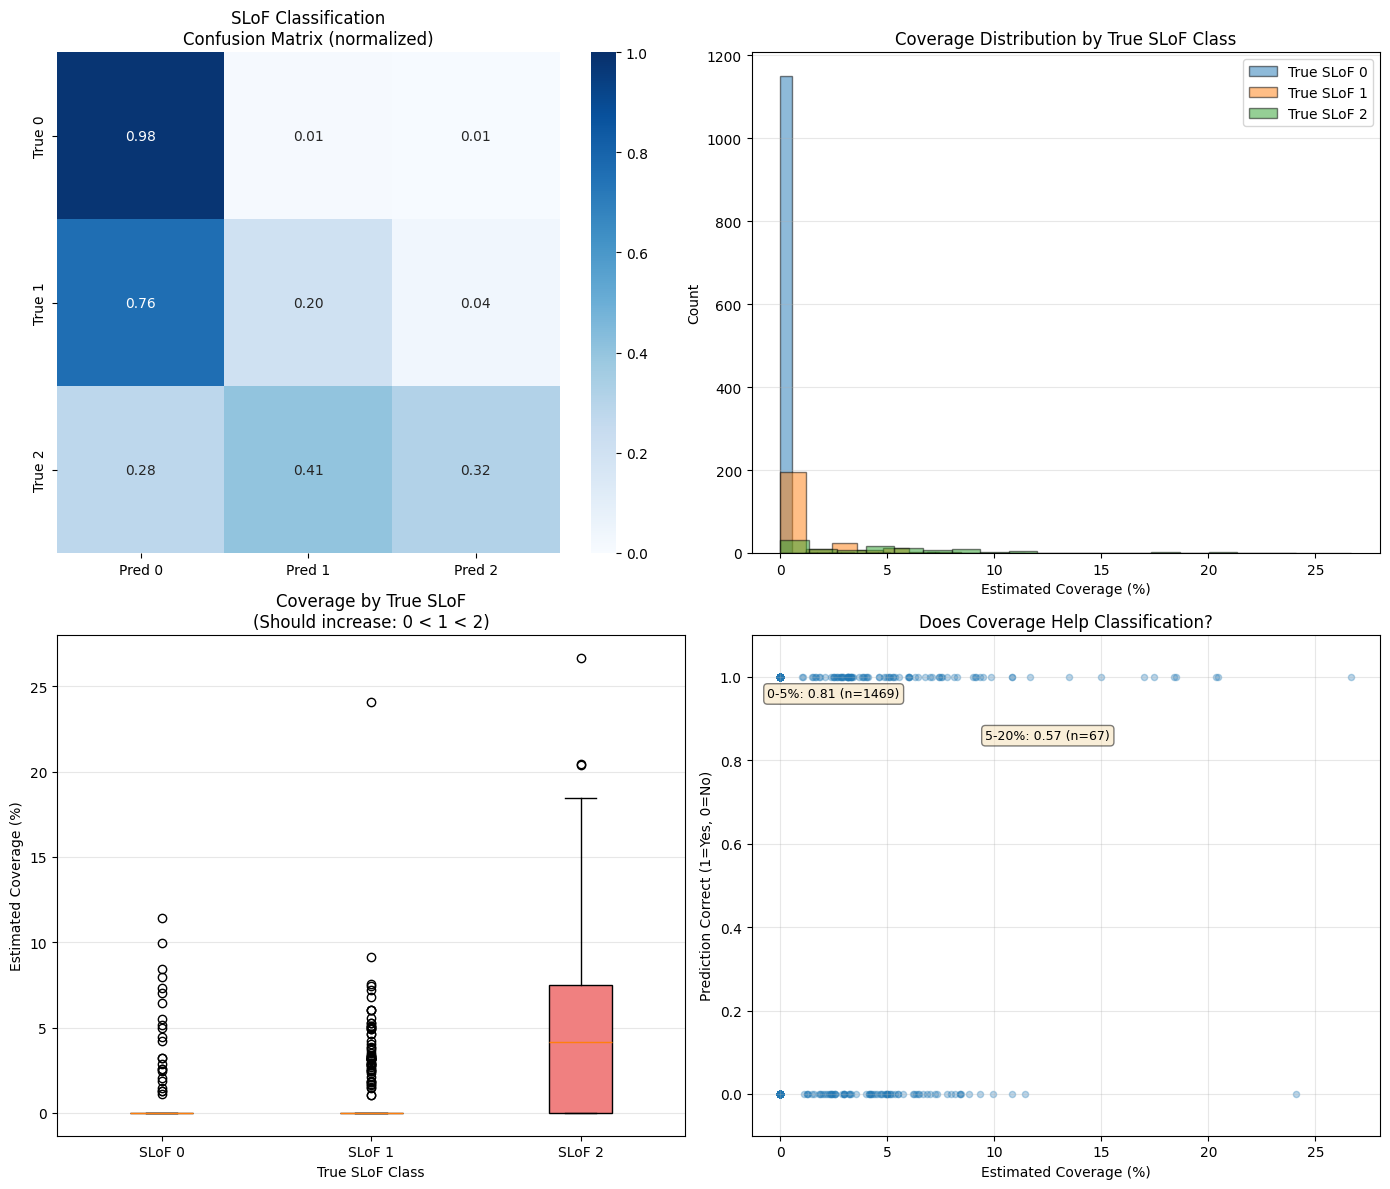

In [14]:
# Estimate coverage on test set using CAM
test_df = test_ds.df
coverage_results = evaluate_coverage(
    model, test_loader, test_df, CONFIG["image_dir"],
    output_dir=CONFIG["output_dir"],
    cam_threshold=CONFIG["cam_threshold"],
    visualize_samples=CONFIG["visualize_samples"]
)

print("\n" + "="*60)
print("  TRAINING AND EVALUATION COMPLETE")
print("="*60)
print(f"  Classification accuracy: {best_val_acc:.3f}")
print(f"  Coverage estimates saved to: {CONFIG['output_dir']}/coverage_estimates.csv")
print(f"  CAM visualizations saved to: {CONFIG['output_dir']}/cam_visualizations/")
print("="*60)
